# MM Decay Analysis

Notebook for multimodal missingness decay analysis on the current `training_runs` layout.
The replicate definition depends on `RETRAIN_OUTER`:

- `RETRAIN_OUTER = False`: each retained `(seed, outer_fold, inner_model_k)` predictor is treated as one trained-model replicate.
- `RETRAIN_OUTER = True`: each `(seed, outer_fold)` outer-refit model is treated as one trained-model replicate.

Configuration in the first code cell:
- `DATASET_NAME`
- `LABEL_NAME`
- `TRAIN_MISSING_LOCATION`
- `RETRAIN_OUTER`

Expected results path:
- `results/<DATASET_NAME>_<LABEL_NAME>/training_runs`
- the notebook filters runs by the `_retraintrue` / `_retrainfalse` tag in the run directory name

Implemented sections:

1. **Results visualization**
- computes replicate-level AUCs using the replicate definition implied by `RETRAIN_OUTER`
- builds mean AUC heatmaps across `(train_missing_prop, test_missing_prop)` cells
- runs a global Friedman test across models
- marks the full heatmap figure when the global Friedman test is significant

2. **Method-level metrics**
- builds a method-level table with four metrics:
  - **Mean baseline performance**: mean AUC at `train_missing = 0` and `test_missing = 0`
  - **Intuition**: the mixed-model slope of AUC versus `train_missing_prop` when `test_missing_prop = 0`; more negative values indicate a stronger reliance on fully observed training inputs
  - **Pure test-time resilience**: mixed-model slope across `test_missing_prop` when `train_missing_prop = 0`
  - **Mean post-adaptation AUC**: mean AUC extracted from the **Post-adaptation Curve**, where for each test missingness level the curve keeps the best AUC achieved across all train missingness levels
- shows a second table where each metric column lists methods ordered from best to worst for that metric
- includes the same line-plot visual format, with the third panel showing the **Post-adaptation Curve**

3. **Condition-level metrics**
- computes pairwise Wilcoxon signed-rank tests with Benjamini-Hochberg FDR correction inside each `(train_missing_prop, test_missing_prop)` condition
- plots pairwise significant `ΔAUC` matrices by condition, ordering methods within each panel by condition-specific mean AUC
- summarizes the top equivalent group against the first significantly lower-ranked method within each condition


In [1]:
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'analysis' else cwd

DATASET_NAME = 'mmCRC'
LABEL_NAME = 'OS_21_label'
TRAIN_MISSING_LOCATION = 'GLOBAL'
RETRAIN_OUTER = False

N_BOOTSTRAP = 2000
BOOTSTRAP_CONFIDENCE = 0.95
BOOTSTRAP_RANDOM_SEED = 42


RESULTS_TAG = f'{DATASET_NAME}_{LABEL_NAME}' if str(LABEL_NAME).strip() else DATASET_NAME
RESULTS_ROOT = PROJECT_ROOT / 'results' / RESULTS_TAG / 'training_runs'
if not RESULTS_ROOT.exists():
    raise FileNotFoundError(
        f'Results root does not exist for dataset={DATASET_NAME!r}, label={LABEL_NAME!r}: {RESULTS_ROOT}'
    )
if not RESULTS_ROOT.is_dir():
    raise NotADirectoryError(f'Expected a directory at: {RESULTS_ROOT}')

RETRAIN_TAG = f"retrain{str(bool(RETRAIN_OUTER)).lower()}"
OUTPUT_DIR = (
    (cwd / 'statistical_tests_outputs') if cwd.name == 'analysis' else (cwd / 'analysis' / 'statistical_tests_outputs')
) / RESULTS_TAG / TRAIN_MISSING_LOCATION.lower() / RETRAIN_TAG
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = OUTPUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ENDPOINT_NAME = LABEL_NAME if str(LABEL_NAME).strip() else RESULTS_ROOT.parent.name.replace(f'{DATASET_NAME}_', '', 1)

RESULTS_ROOT


PosixPath('/Users/marcalbesa/Desktop/TFM/git_exp/methods/results/mmCRC_OS_21_label/training_runs')

In [2]:
import sys
import pandas as pd

ANALYSIS_DIR = cwd if cwd.name == 'analysis' else (cwd / 'analysis')
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

import results_analysis as ra

HAVE_MPL = ra.HAVE_MPL
resolve_requested_model_names = ra.resolve_requested_model_names
load_all_test_predictions = ra.load_all_test_predictions
expand_inner_model_predictions = ra.expand_inner_model_predictions
aggregate_member_patient_predictions = ra.aggregate_member_patient_predictions
build_replicate_auc_table = ra.build_replicate_auc_table
build_level1_summary = ra.build_level1_summary
build_method_plot_summary = ra.build_method_plot_summary
build_method_level_metrics = ra.build_method_level_metrics
build_metric_ordering_table = ra.build_metric_ordering_table
plot_method_line_triplet = ra.plot_method_line_triplet
compute_level1_global_friedman = ra.compute_level1_global_friedman
plot_level1_auc_heatmaps = ra.plot_level1_auc_heatmaps
compute_level2_pairwise_tests = ra.compute_level2_pairwise_tests
select_level2_plot_pairs = ra.select_level2_plot_pairs
plot_level2_significant_pairs_heatmap = ra.plot_level2_significant_pairs_heatmap
plot_level3_pairwise_condition_matrices = ra.plot_level3_pairwise_condition_matrices


## Results visualization

Mean AUC heatmaps across train/test missingness conditions, with a global Friedman test across models.

Each heatmap cell reports `mean AUC ± 95% CI`. A `*` at the figure level indicates that the global Friedman test is significant (`p < 0.05`).


In [3]:
REQUESTED_MODEL_NAMES = resolve_requested_model_names(
    results_root=RESULTS_ROOT,
    dataset_name=DATASET_NAME,
    train_missing_location=TRAIN_MISSING_LOCATION,
    retrain_outer=RETRAIN_OUTER,
)
if not REQUESTED_MODEL_NAMES:
    raise ValueError('No model folders were detected for the requested dataset / location / retrain flag.')

raw_predictions_df, missing_prediction_files = load_all_test_predictions(
    results_root=RESULTS_ROOT,
    dataset_name=DATASET_NAME,
    train_missing_location=TRAIN_MISSING_LOCATION,
    model_names=REQUESTED_MODEL_NAMES,
    retrain_outer=RETRAIN_OUTER,
)
if raw_predictions_df.empty:
    raise ValueError('No test_predictions.csv files with retained inner-model probabilities were found.')

member_prediction_df = expand_inner_model_predictions(raw_predictions_df)
member_patient_df = aggregate_member_patient_predictions(member_prediction_df)
replicate_auc_df = build_replicate_auc_table(member_patient_df)
level1_summary_df = build_level1_summary(replicate_auc_df=replicate_auc_df)
level1_global_friedman_df = compute_level1_global_friedman(level1_summary_df)
method_plot_summary_df = build_method_plot_summary(
    replicate_auc_df=replicate_auc_df,
    n_bootstrap=N_BOOTSTRAP,
    confidence=BOOTSTRAP_CONFIDENCE,
    random_seed=BOOTSTRAP_RANDOM_SEED,
)
method_level_metrics_df, post_adaptation_envelope_df = build_method_level_metrics(
    replicate_auc_df=replicate_auc_df,
    level1_df=level1_summary_df,
)
method_metric_ordering_df = build_metric_ordering_table(method_level_metrics_df)

replicate_auc_path = OUTPUT_DIR / 'replicate_auc_table.csv'
method_condition_summary_path = OUTPUT_DIR / 'method_condition_mean_auc_summary.csv'
level1_global_friedman_path = OUTPUT_DIR / 'level1_global_friedman.csv'
method_plot_summary_path = OUTPUT_DIR / 'method_plot_summary.csv'
method_level_metrics_path = OUTPUT_DIR / 'method_level_metrics.csv'
method_metric_ordering_path = OUTPUT_DIR / 'method_metric_orderings.csv'
post_adaptation_envelope_path = OUTPUT_DIR / 'resilience_post_adaptation_envelope.csv'

replicate_auc_df.to_csv(replicate_auc_path, index=False)
level1_summary_df.to_csv(method_condition_summary_path, index=False)
level1_global_friedman_df.to_csv(level1_global_friedman_path, index=False)
method_plot_summary_df.to_csv(method_plot_summary_path, index=False)
method_level_metrics_df.to_csv(method_level_metrics_path, index=False)
method_metric_ordering_df.to_csv(method_metric_ordering_path, index=False)
post_adaptation_envelope_df.to_csv(post_adaptation_envelope_path, index=False)

replicate_unit_label = 'seed x outer_fold' if bool(RETRAIN_OUTER) else 'seed x outer_fold x inner_model_k'
print(f'Replicate unit: {replicate_unit_label}')
print('Saved:', replicate_auc_path)
print('Saved:', method_condition_summary_path)
print('Saved:', level1_global_friedman_path)
print('Saved:', method_plot_summary_path)
print('Saved:', method_level_metrics_path)
print('Saved:', method_metric_ordering_path)
print('Saved:', post_adaptation_envelope_path)


Replicate unit: seed x outer_fold x inner_model_k
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/mmCRC_OS_21_label/global/retrainfalse/replicate_auc_table.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/mmCRC_OS_21_label/global/retrainfalse/method_condition_mean_auc_summary.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/mmCRC_OS_21_label/global/retrainfalse/level1_global_friedman.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/mmCRC_OS_21_label/global/retrainfalse/method_plot_summary.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/mmCRC_OS_21_label/global/retrainfalse/method_level_metrics.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/mmCRC_OS_21_label/global/retrainfalse/method_metric_orderings.csv
Saved: /Users/marcalbesa/Des

Global Friedman test across heatmap cells:


,n_cells,n_models,friedman_statistic,p_value,significant_p0_05
0,12,7,31.964286,0.000017,True


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/mmCRC_OS_21_label/global/retrainfalse/figures/level1_7models.png


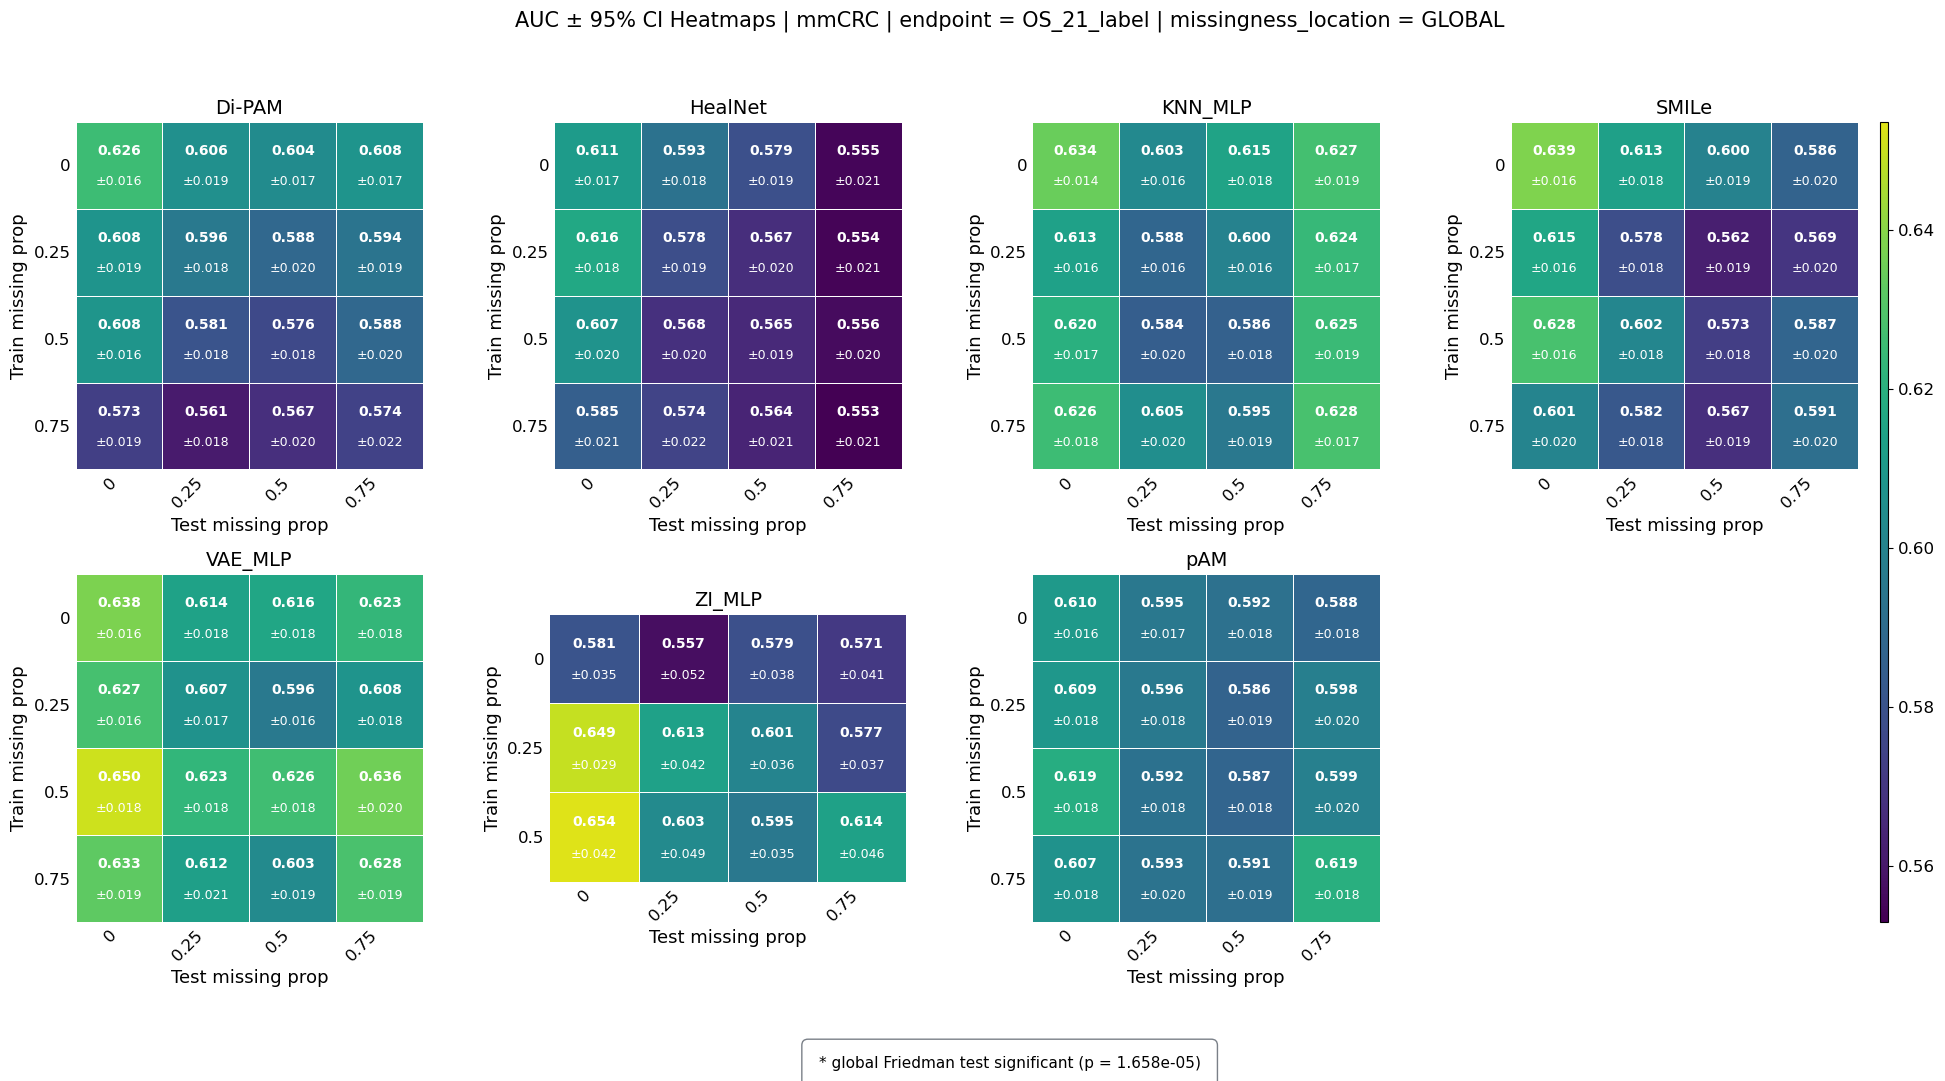

In [4]:
print('Global Friedman test across heatmap cells:')
display(level1_global_friedman_df)

level1_model_count_tag = f"{level1_summary_df['model_name'].nunique()}models" if not level1_summary_df.empty else '0models'
if HAVE_MPL:
    plot_level1_auc_heatmaps(
        summary_df=method_plot_summary_df,
        friedman_global_df=level1_global_friedman_df,
        title=f'AUC ± 95% CI Heatmaps | {DATASET_NAME} | endpoint = {ENDPOINT_NAME} | missingness_location = {TRAIN_MISSING_LOCATION}',
        figures_dir=FIGURES_DIR,
        file_name=f'level1_{level1_model_count_tag}.png',
    )
else:
    print('Matplotlib not available; skipping level 1 heatmap plot.')


## Method-level metrics

Method-level summary table built from trained-model replicate AUCs.

`Intuition` is the mixed-model slope of AUC versus train missingness when test data remain complete. More negative values indicate a stronger reliance on complete training inputs.

`Pure test-time resilience` is the mixed-model slope of AUC versus test missingness when training remains complete. Less negative values indicate better intrinsic robustness to missingness at test time.

`Mean post-adaptation AUC` is obtained from the **Post-adaptation Curve**, which keeps, for each test missingness level, the highest mean AUC reachable across all train missingness levels. It summarizes the best average performance achievable after adapting the training missingness regime.

NOTE: Distillation-based methods are excluded from the `Intuition` analysis, because their teacher depends on fully observed inputs. For those methods, the reported `train_missing_prop` corresponds to the student missingness level, so it is not directly comparable as an `Intuition` estimate.


Method-level metrics:


,Model,Mean baseline performance,Intuition,Pure test-time resilience,Mean post-adaptation AUC
0,SMILe,0.6385,-0.0404,-0.0680,0.6107
1,VAE_MLP,0.6377,0.0031,-0.0171,0.6338
2,KNN_MLP,0.6344,-0.0080,-0.0039,0.6205
3,Di-PAM,0.6256,-0.0633,-0.0220,0.6107
4,HealNet,0.6106,-0.0345,-0.0727,0.5861
5,pAM,0.6098,0.0003,-0.0278,0.6066
6,ZI_MLP,0.5806,0.1459,-0.0026,0.6204


Methods ordered by metric:


,Mean baseline performance,Intuition,Pure test-time resilience,Mean post-adaptation AUC
0,SMILe,ZI_MLP,ZI_MLP,VAE_MLP
1,VAE_MLP,VAE_MLP,KNN_MLP,KNN_MLP
2,KNN_MLP,pAM,VAE_MLP,ZI_MLP
3,Di-PAM,KNN_MLP,Di-PAM,Di-PAM
4,HealNet,HealNet,pAM,SMILe
5,pAM,SMILe,SMILe,pAM
6,ZI_MLP,Di-PAM,HealNet,HealNet


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/mmCRC_OS_21_label/global/retrainfalse/figures/method_level_mean_auc_curves_mmCRC_OS_21_label_global.png


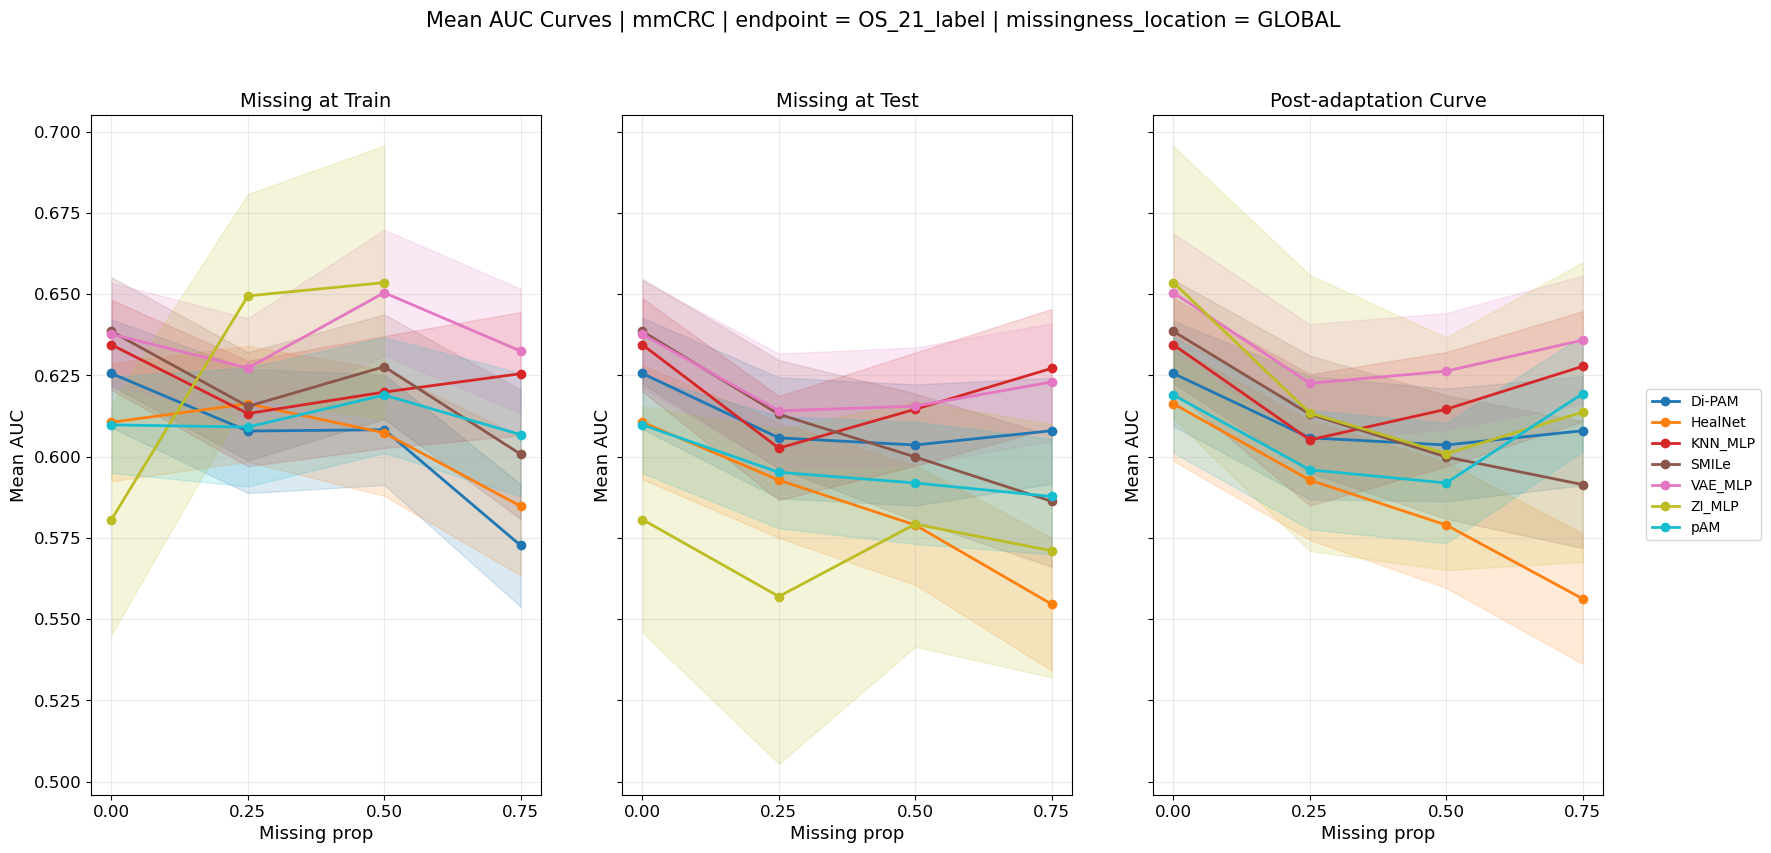

In [5]:
method_level_display_df = (
    method_level_metrics_df[[
        'model_name',
        'baseline_mean_auc',
        'intuition_slope',
        'pure_test_time_resilience_slope',
        'resilience_post_adaptation_mean_auc',
    ]]
    .rename(columns={
        'model_name': 'Model',
        'baseline_mean_auc': 'Mean baseline performance',
        'intuition_slope': 'Intuition',
        'pure_test_time_resilience_slope': 'Pure test-time resilience',
        'resilience_post_adaptation_mean_auc': 'Mean post-adaptation AUC',
    })
)

print('Method-level metrics:')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000):
    display(method_level_display_df.round(4))

print('Methods ordered by metric:')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000):
    display(method_metric_ordering_df)

if HAVE_MPL:
    plot_method_line_triplet(
        summary_df=method_plot_summary_df,
        metric_col='mean_auc',
        title=f'Mean AUC Curves | {DATASET_NAME} | endpoint = {ENDPOINT_NAME} | missingness_location = {TRAIN_MISSING_LOCATION}',
        ylabel='Mean AUC',
        figures_dir=FIGURES_DIR,
        file_name=f'method_level_mean_auc_curves_{RESULTS_TAG}_{TRAIN_MISSING_LOCATION.lower()}.png',
    )
else:
    print('Matplotlib not available; skipping method-level line plots.')


## Condition-level metrics

Pairwise significant `ΔAUC` matrices by missingness condition.
Within each panel, methods are ordered by condition-specific mean AUC, so rank positions may change from one condition to another.
Only pairs that remain significant after Wilcoxon signed-rank testing with Benjamini-Hochberg FDR correction are highlighted.


Saved: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/mmCRC_OS_21_label/global/retrainfalse/wilcoxon_significant.csv
Significant pairwise comparisons: 74
Condition-summary heatmap cells: 12
Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/mmCRC_OS_21_label/global/retrainfalse/figures/level2_pairwise_condition_matrices_mmCRC_OS_21_label_global_7models.png


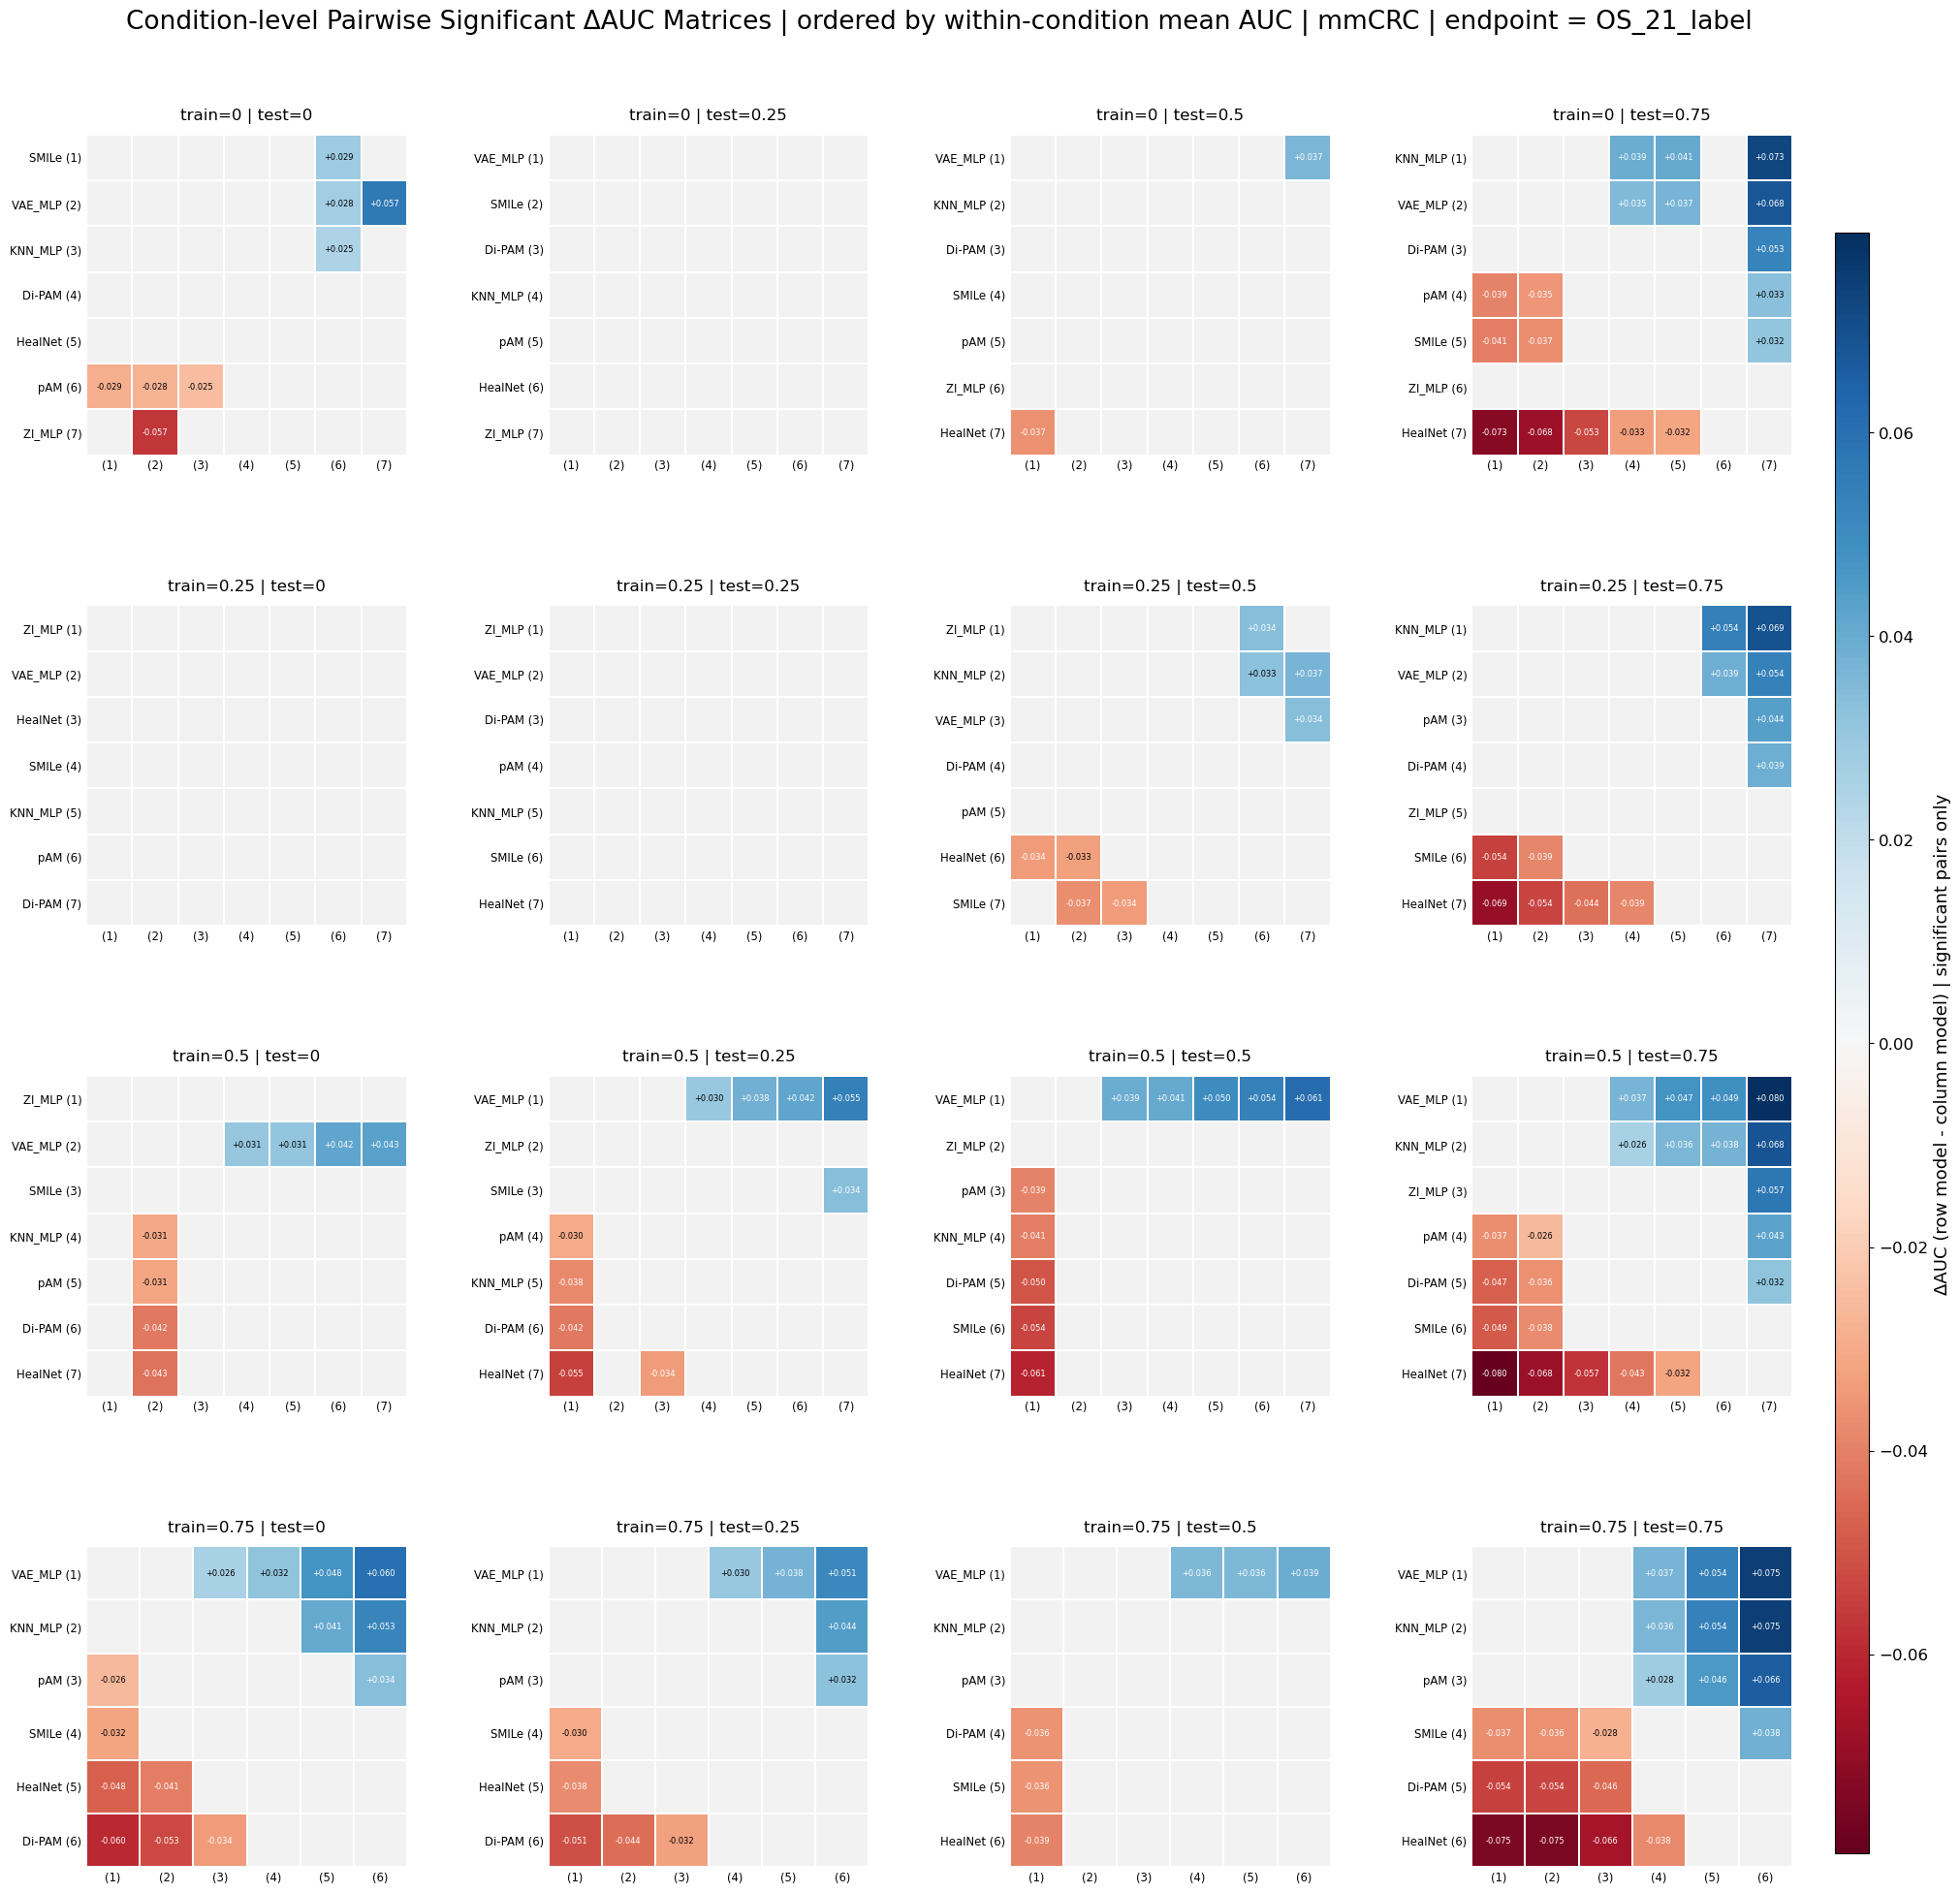

In [6]:
level2_pairwise_df = compute_level2_pairwise_tests(
    level1_df=level1_summary_df,
    replicate_auc_df=replicate_auc_df,
)
level2_plot_df = select_level2_plot_pairs(level2_pairwise_df)

root_tag = RESULTS_ROOT.parent.name
location_tag = TRAIN_MISSING_LOCATION.lower()
model_count_tag = f"{level1_summary_df['model_name'].nunique()}models" if not level1_summary_df.empty else '0models'

level2_significant_pairs_df = (
    level2_pairwise_df.loc[level2_pairwise_df['significant_fdr_0p05']]
    .sort_values(['winner_model', 'loser_model', 'train_missing_prop', 'test_missing_prop'])
    .reset_index(drop=True)
)

level2_significant_path = OUTPUT_DIR / 'wilcoxon_significant.csv'
level2_significant_pairs_df.to_csv(level2_significant_path, index=False)
print('Saved:', level2_significant_path)
print('Significant pairwise comparisons:', len(level2_significant_pairs_df))
print('Condition-summary heatmap cells:', len(level2_plot_df))

if HAVE_MPL:
    plot_level3_pairwise_condition_matrices(
        level2_pairwise_df=level2_pairwise_df,
        title=f'Condition-level Pairwise Significant ΔAUC Matrices | ordered by within-condition mean AUC | {DATASET_NAME} | endpoint = {ENDPOINT_NAME}',
        figures_dir=FIGURES_DIR,
        file_name=f'level2_pairwise_condition_matrices_{root_tag}_{location_tag}_{model_count_tag}.png',
    )
else:
    print('Matplotlib not available; skipping condition-level pairwise ΔAUC matrices.')



### Top equivalent group vs first significantly lower-ranked method

Condition-level summary heatmap derived from the same Wilcoxon signed-rank + FDR results.
Each cell shows the top equivalent group of methods that are all significantly better than the first lower-ranked loser; the number in parentheses gives the loser position in the within-condition mean-AUC ranking.


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/statistical_tests_outputs/mmCRC_OS_21_label/global/retrainfalse/figures/level3_significant_pairs_mmCRC_OS_21_label_global_7models.png


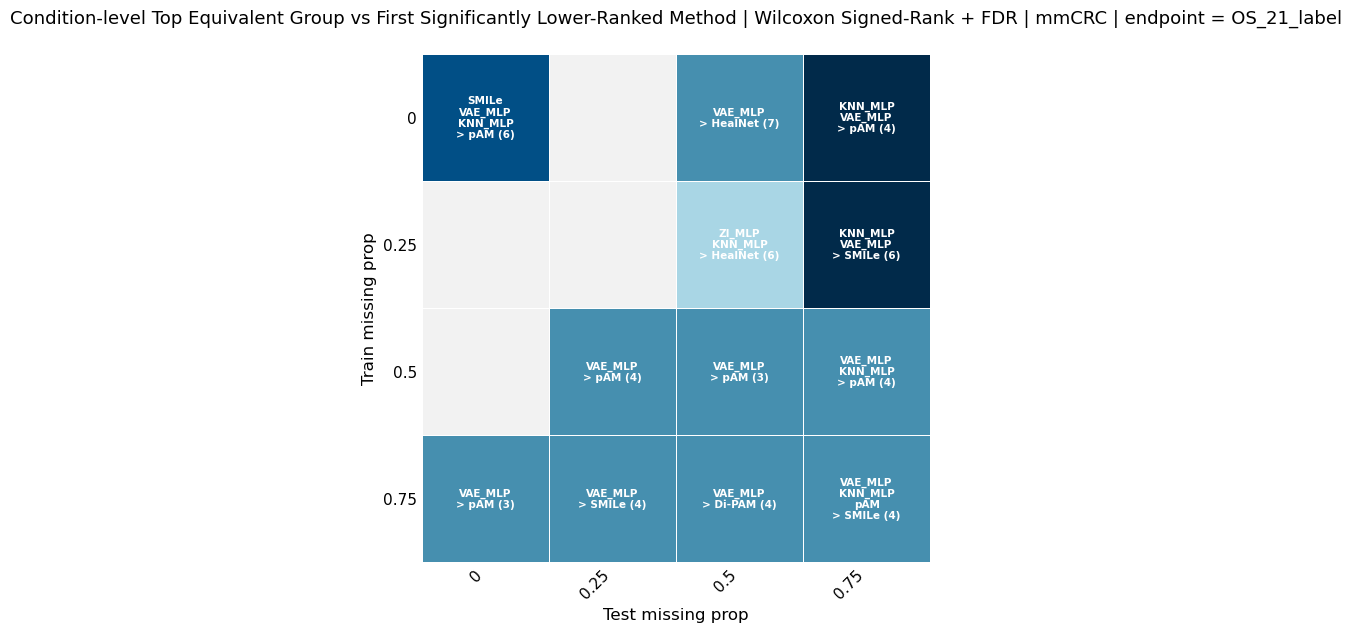

In [7]:
if HAVE_MPL:
    plot_level2_significant_pairs_heatmap(
        level2_plot_df=level2_plot_df,
        title=f'Condition-level Top Equivalent Group vs First Significantly Lower-Ranked Method | Wilcoxon Signed-Rank + FDR | {DATASET_NAME} | endpoint = {ENDPOINT_NAME}',
        figures_dir=FIGURES_DIR,
        file_name=f'level3_significant_pairs_{root_tag}_{location_tag}_{model_count_tag}.png',
    )
else:
    print('Matplotlib not available; skipping condition-level summary heatmap.')
